In [2]:
import numpy as np
from numpy.typing import NDArray
import cv2 as cv
import matplotlib.pyplot as plt
from utils import plot_two_img

# Конвертация между цветовыми пространствами

In [2]:
def calc_H(R, G, B, i, j):
    M = max(R[i, j], G[i, j], B[i, j])
    m = min(R[i, j], G[i, j], B[i, j])
    C = M - m
    if C == 0:
        return 0.0, M, m, C

    if M == R[i, j]:
        h = ((G[i, j] - B[i, j]) / C) % 6
    elif M == G[i, j]:
        h = (B[i, j] - R[i, j]) / C + 2
    elif M == B[i, j]:
        h = (R[i, j] - G[i, j]) / C + 4
    H = 60 * h
    return H, M, m, C


def rgb2hsl(img: NDArray) -> NDArray:
    hsl_img = np.zeros_like(img, dtype=np.float32)
    R = img[:, :, 0] / 255
    G = img[:, :, 1] / 255
    B = img[:, :, 2] / 255
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            H, M, m, C = calc_H(R, G, B, i, j)
            L = (M + m) / 2
            S = 0 if L == 0 or L == 1 else C / (1 - abs(2 * L - 1))
            hsl_img[i, j, 0] = H / 2
            hsl_img[i, j, 2] = S * 255
            hsl_img[i, j, 1] = L * 255

    hsl_img = hsl_img.clip(0, 255).astype("uint8")
    return hsl_img


def rgb2hsv(img: NDArray) -> NDArray:
    hsv_img = np.zeros_like(img, dtype=np.float32)
    R = img[:, :, 0] / 255
    G = img[:, :, 1] / 255
    B = img[:, :, 2] / 255
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            H, M, m, C = calc_H(R, G, B, i, j)
            V = M
            S = 0 if V == 0 else C / V
            hsv_img[i, j, 0] = H / 2
            hsv_img[i, j, 1] = S * 255
            hsv_img[i, j, 2] = V * 255

    hsv_img = hsv_img.clip(0, 255).astype("uint8")
    return hsv_img

# HSV

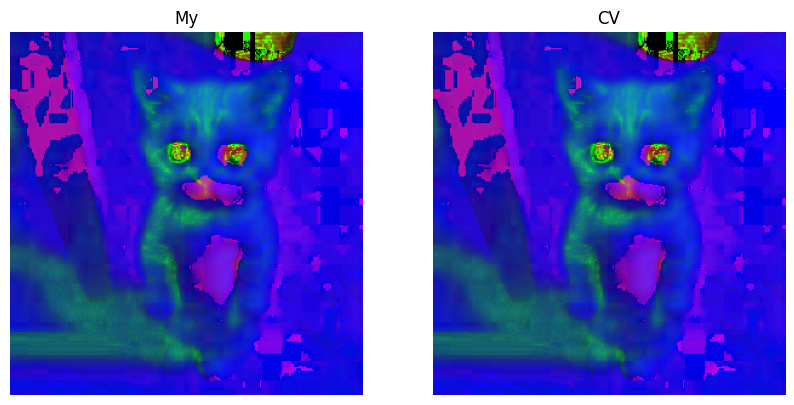

In [3]:
img = cv.imread('cat.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
hsv_img = cv.cvtColor(img, cv.COLOR_RGB2HSV)
my_hsv_img = rgb2hsv(img)

plot_two_img(my_hsv_img, hsv_img)

# HLS

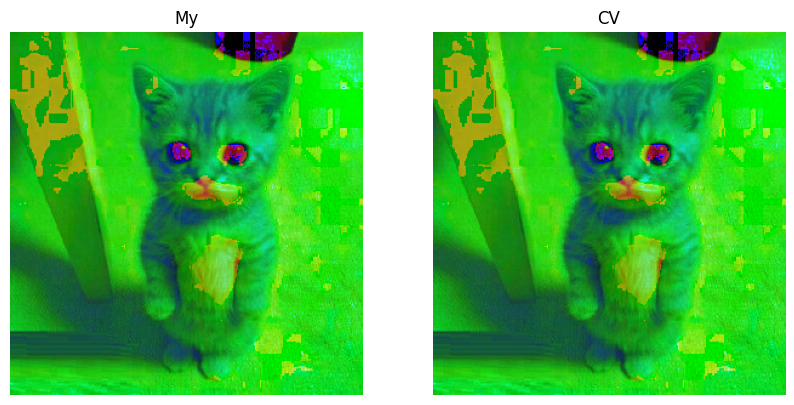

In [4]:
img = cv.imread('cat.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
hsl_img = cv.cvtColor(img, cv.COLOR_RGB2HLS)
my_hsl_img = rgb2hsl(img)

plot_two_img(my_hsl_img, hsl_img)

# Blending

In [5]:
def my_blending(img1: NDArray, alpha: float, img2: NDArray, beta: float, gamma: float) -> NDArray:
    new_img = img1 * alpha + img2 * beta + gamma
    return new_img.clip(0, 255).astype("uint8")

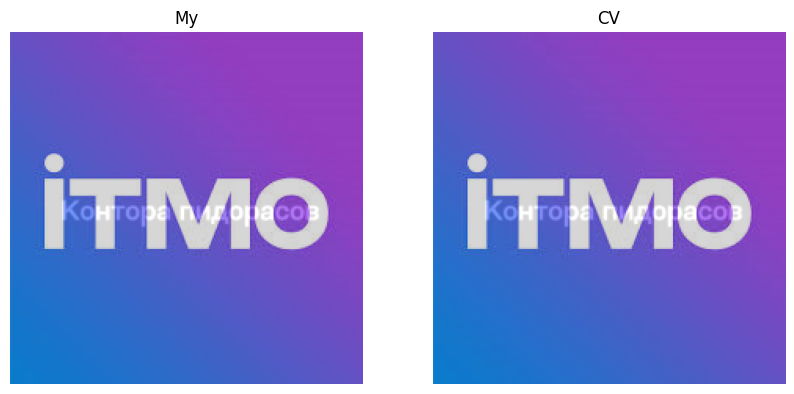

In [6]:
itmo = cv.imread('itmo.png', cv.IMREAD_COLOR_RGB)
kontora = cv.imread('kontora.png', cv.IMREAD_COLOR_RGB)
kontora = cv.resize(kontora, (225, 225))
my_blend = my_blending(itmo, 0.8, kontora, 0.2, 10.0)
blend = cv.addWeighted(itmo, 0.8, kontora, 0.2, 10.0)

plot_two_img(my_blend, blend)

# Пороговая обработка

In [56]:
def binary(img: NDArray, threshold: int, max_val: int) -> NDArray:
    return np.where(img >= threshold, max_val, 0)


def binary_inv(img: NDArray, threshold: int, max_val: int) -> NDArray:
    return np.where(img >= threshold, 0, max_val)


def to_zero(img: NDArray, threshold: int) -> NDArray:
    return np.where(img >= threshold, img, 0)


def to_zero_inv(img: NDArray, threshold: int) -> NDArray:
    return np.where(img >= threshold, 0, img)


def truncate(img: NDArray, threshold: int) -> NDArray:
    return np.where(img >= threshold, threshold, img)


def gaussian_kernel_2d(ksize: int) -> NDArray[np.float32]:
    sigma = 0.3 * ((ksize - 1) * 0.5 - 1) + 0.8
    r = ksize // 2
    x, y = np.mgrid[-r:r + 1, -r:r + 1]
    kernel = np.exp(-(x ** 2 + y ** 2) / (2 * sigma ** 2))
    return kernel / kernel.sum()


def adaptive_gaussian(img: NDArray, kernel_size: int, C: int) -> NDArray:
    new_img = img.copy()
    r = kernel_size // 2
    g = gaussian_kernel_2d(kernel_size)
    padded = np.pad(img, ((r, r), (r, r)), mode="edge")
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            threshold = (padded[i:i + kernel_size, j:j + kernel_size].flatten() @ g.flatten()) - C
            new_img[i, j] = 0 if img[i, j] <= threshold else 255

    return new_img

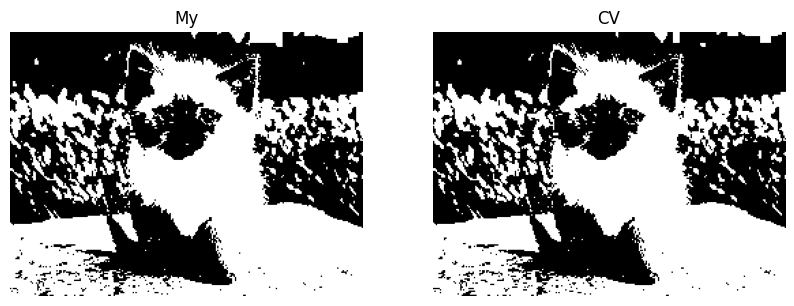

In [8]:
cat = cv.imread('cat2.png', cv.IMREAD_GRAYSCALE)
my_bin_cat = binary(cat, 127, 255)
ret, bin_cat = cv.threshold(cat, 127, 255, cv.THRESH_BINARY)
plot_two_img(my_bin_cat, bin_cat, cmap='gray')

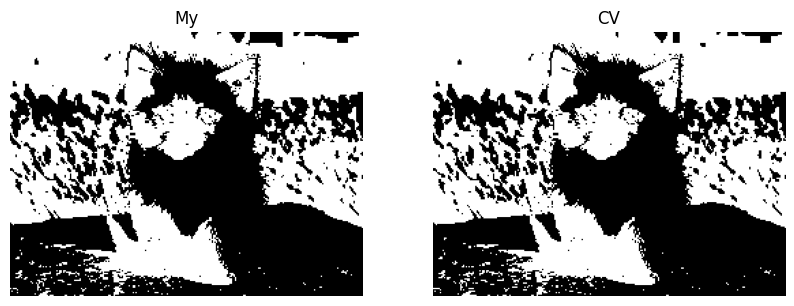

In [9]:
my_int_bin_cat = binary_inv(cat, 127, 255)
ret, bin_inv_cat = cv.threshold(cat, 127, 255, cv.THRESH_BINARY_INV)
plot_two_img(my_int_bin_cat, bin_inv_cat, cmap='gray')

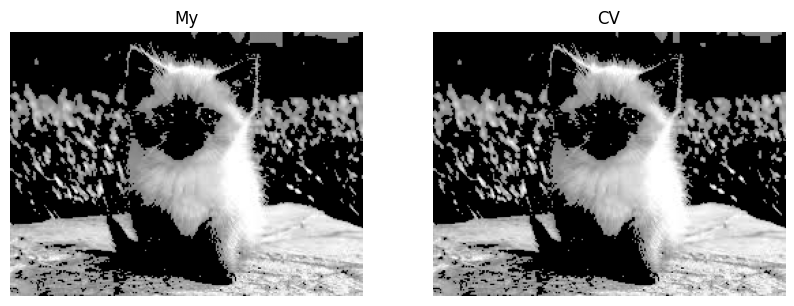

In [10]:
my_to_zero_cat = to_zero(cat, 127)
ret, to_zero_cat = cv.threshold(cat, 127, 255, cv.THRESH_TOZERO)
plot_two_img(my_to_zero_cat, to_zero_cat, cmap='gray')

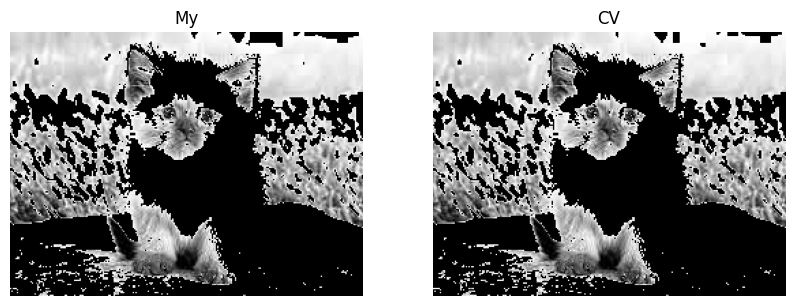

In [11]:
my_to_zero_inv_cat = to_zero_inv(cat, 127)
ret, to_zero_inv_cat = cv.threshold(cat, 127, 255, cv.THRESH_TOZERO_INV)
plot_two_img(my_to_zero_inv_cat, to_zero_inv_cat, cmap='gray')

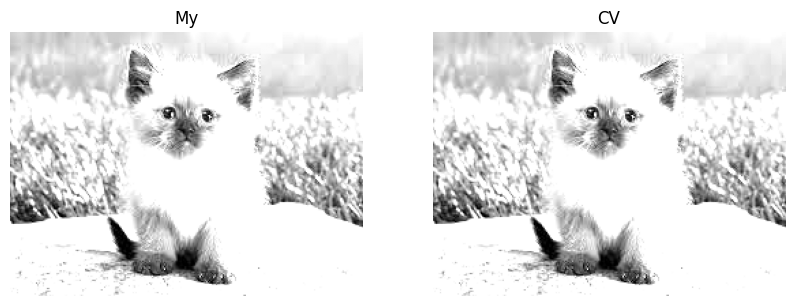

In [12]:
my_truncate_cat = truncate(cat, 127)
ret, truncate_cat = cv.threshold(cat, 127, 255, cv.THRESH_TRUNC)
plot_two_img(my_truncate_cat, truncate_cat, cmap='gray')

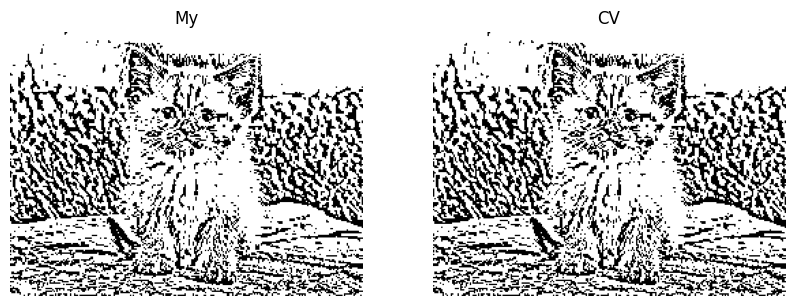

In [57]:
my_gaussian_cat = adaptive_gaussian(cat, 11, 5)
gaussian_cat = cv.adaptiveThreshold(cat, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 5)
plot_two_img(my_gaussian_cat, gaussian_cat, cmap='gray')

# Размытие и сглаживание

In [67]:
my_kernel = np.array([[1, 5, -1],
                      [-5, 0, -5],
                      [-1, 5, 1]])

def filter2d(img : NDArray, kernel: NDArray) -> NDArray:
    res_img = np.zeros_like(img, dtype=np.float64)
    p = kernel.shape[0] // 2
    padded = np.pad(img, ((p, p), (p, p)), mode='edge')
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            res_img[i, j] = padded[i : i + kernel.shape[0], j : j + kernel.shape[1]].flatten() @ kernel.flatten()

    return res_img.clip(0, 255)

def median_blur(img: NDArray, kernel_size: int) -> NDArray:
    res_img = np.zeros_like(img)
    p = kernel_size // 2
    padded = np.pad(img, ((p, p), (p, p)), mode='edge')
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            window = padded[i : i + kernel_size, j : j + kernel_size]
            res_img[i, j] = np.median(window)

    return res_img


def gaussian_kernel_2d(ksize: int, sigma: float) -> NDArray[np.float32]:
    r = ksize // 2
    x, y = np.mgrid[-r:r + 1, -r:r + 1]
    kernel = np.exp(-(x ** 2 + y ** 2) / (2 * sigma ** 2))
    return kernel / kernel.sum()

def gaussian_blur(img:NDArray, ksize: int, sigma: float) -> NDArray:
    res_img = np.zeros_like(img, dtype=np.float64)
    p = ksize // 2
    padded = np.pad(img, ((p, p), (p, p)), mode='edge')
    g = gaussian_kernel_2d(ksize, sigma)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            window = padded[i : i + ksize, j : j + ksize]
            res_img[i, j] = window.flatten() @ g.flatten()

    return res_img.clip(0, 255)

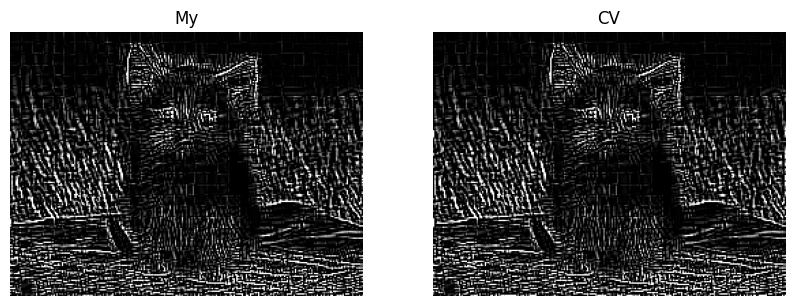

In [55]:
cat = cv.imread('cat2.png', cv.IMREAD_GRAYSCALE)
my_filter_cat = filter2d(cat, my_kernel)
filter_cat = cv.filter2D(cat, ddepth=-1, kernel=my_kernel)
plot_two_img(my_filter_cat, filter_cat, cmap='gray')

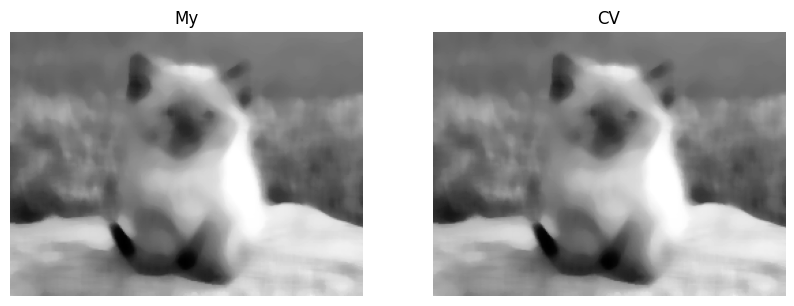

In [37]:
my_median_blur_cat = median_blur(cat, 11)
median_blur_cat = cv.medianBlur(cat, 11)
plot_two_img(my_median_blur_cat, median_blur_cat, cmap='gray')

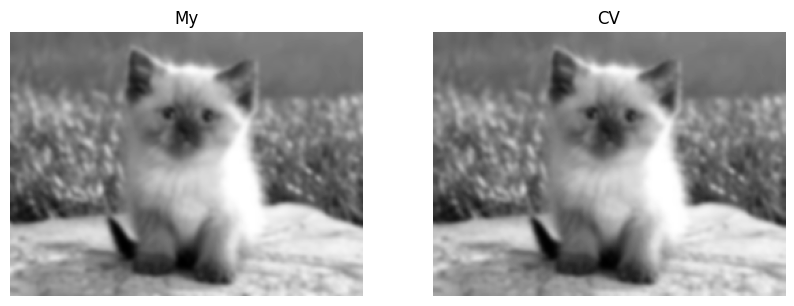

In [72]:
my_gaussian_blur_cat = gaussian_blur(cat, 11, 1.5)
gaussian_blur_cat = cv.GaussianBlur(cat, (11, 11), 1.5)
plot_two_img(my_gaussian_blur_cat, gaussian_blur_cat, cmap='gray')

# Применение фильтра Собеля

In [80]:
def filter2d(img : NDArray, kernel: NDArray) -> NDArray:
    res_img = np.zeros_like(img, dtype=np.float64)
    p = kernel.shape[0] // 2
    padded = np.pad(img, ((p, p), (p, p)), mode='edge')
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            res_img[i, j] = padded[i : i + kernel.shape[0], j : j + kernel.shape[1]].flatten() @ kernel.flatten()

    return res_img

Gx = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]])
Gy = np.array([[-1, -2, -1],
               [0, 0, 0],
               [1, 2, 1]])

def sobel_filter(img):
    x = filter2d(img, Gx)
    y = filter2d(img, Gy)
    res = np.sqrt(x**2 + y**2)
    return res.clip(0, 255)

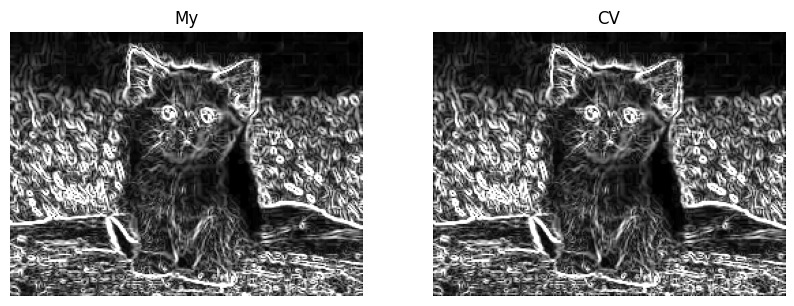

In [81]:
my_sobel_cat = sobel_filter(cat)
sobelx = cv.Sobel(cat, cv.CV_64F, 1, 0, ksize=3)
sobely = cv.Sobel(cat, cv.CV_64F, 0, 1, ksize=3)
gradient_magnitude = cv.magnitude(sobelx, sobely)
gradient_magnitude = cv.convertScaleAbs(gradient_magnitude)
plot_two_img(my_sobel_cat, gradient_magnitude, cmap='gray')

# Эквализация гистограммы для чёрно-белых фотографий


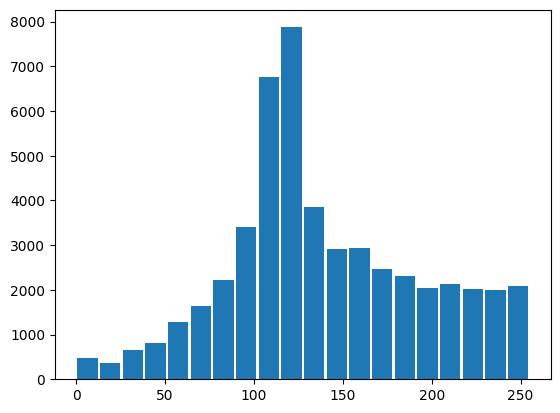

In [28]:
cat = cv.imread('cat2.png', cv.IMREAD_GRAYSCALE)
plt.hist(cat.flatten(), bins=20, rwidth=0.9)
plt.show()

In [20]:
cat.shape

(194, 259)

In [23]:
def equalization(img: NDArray):
    hist, bins = np.histogram(img.flatten(), 256, [0, 256])
    cdf: NDArray = hist.cumsum()
    res = img.copy()
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            h = np.round((cdf[img[i, j]] - cdf.min()) / (img.shape[0] * img.shape[1] - cdf.min()) * 255)
            res[i, j] = h
    return res

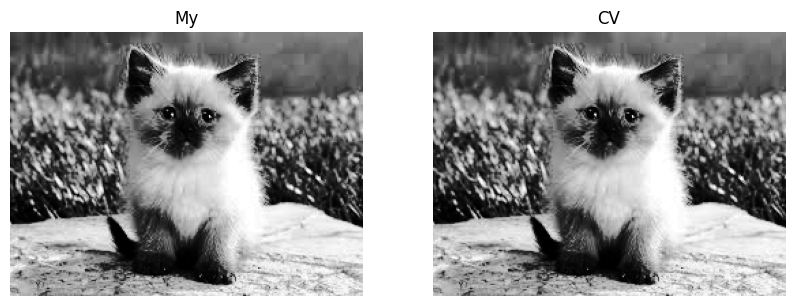

In [25]:
my_eq = equalization(cat)
eq = cv.equalizeHist(cat)
plot_two_img(my_eq, eq, cmap='gray')

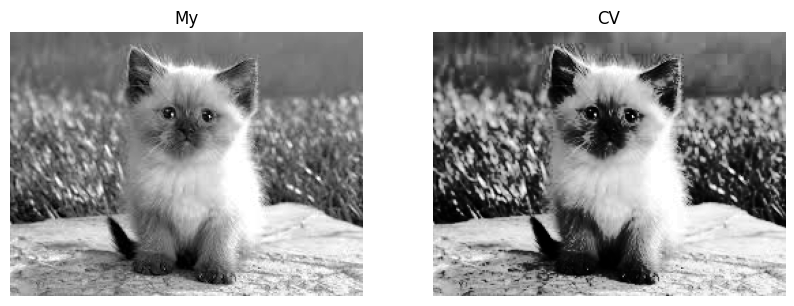

In [26]:
plot_two_img(cat, eq, cmap='gray')